In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
'''骨架提取后的图片数据集载入，划分训练集测试集'''
import torch
import torchvision
from torch.utils.data import DataLoader, random_split
from torchvision import transforms
transform1 = transforms.Compose([
    transforms.Resize([128, 128]),
    transforms.ToTensor(),
    transforms.Normalize(mean=[.5,.5,.5],std=[.5,.5,.5])
])
transform2 = transforms.Compose([
    transforms.Resize([300, 300]),
    transforms.RandomCrop([128, 128]), #随机裁剪
    transforms.ToTensor(),
    transforms.Normalize(mean=[.5,.5,.5],std=[.5,.5,.5])
])
transform3 = transforms.Compose([
    transforms.Resize([128, 128]),
    transforms.RandomAffine(20),  #随机仿射变化
    transforms.ToTensor(),
    transforms.Normalize(mean=[.5,.5,.5],std=[.5,.5,.5])
])
transform4 = transforms.Compose([
    transforms.Resize([128, 128]),
    transforms.RandomEqualize(0.9),  #概率直方图均衡
    transforms.ToTensor(),
    transforms.Normalize(mean=[.5,.5,.5],std=[.5,.5,.5])
])
transform5 = transforms.Compose([
    transforms.Resize([128, 128]),
    transforms.RandomHorizontalFlip(p=1),  #水平翻转
    transforms.ToTensor(),
    transforms.Normalize(mean=[.5,.5,.5],std=[.5,.5,.5])
])
transform6 = transforms.Compose([
    transforms.Resize([128, 128]),
    transforms.ColorJitter(brightness=(0.5, 2)),  #亮度在0.5-2之间随机取值进行变化
    transforms.ToTensor(),
    transforms.Normalize(mean=[.5,.5,.5],std=[.5,.5,.5])
])
transform7 = transforms.Compose([
    transforms.Resize([128, 128]),
    transforms.ColorJitter(contrast=(0.5, 2)),  #对比度在0.5-2之间随机取值进行变化
    transforms.ToTensor(),
    transforms.Normalize(mean=[.5,.5,.5],std=[.5,.5,.5])
])
transform8 = transforms.Compose([
    transforms.Resize([128, 128]),
    transforms.ColorJitter(saturation=(0.5, 2)),  #饱和度在0.5-2之间随机取值进行变化
    transforms.ToTensor(),
    transforms.Normalize(mean=[.5,.5,.5],std=[.5,.5,.5])
])
train_path ='/content/drive/MyDrive/yoga/yoga_pose_solo_evaluated_splited/train/downdog'
test_path ='/content/drive/MyDrive/yoga/yoga_pose_solo_evaluated_splited/test/downdog'
data1 = torchvision.datasets.ImageFolder(root=train_path,transform=transform1) 
data2 = torchvision.datasets.ImageFolder(root=train_path,transform=transform2)
data3 = torchvision.datasets.ImageFolder(root=train_path,transform=transform3)
data4 = torchvision.datasets.ImageFolder(root=train_path,transform=transform4)
data5 = torchvision.datasets.ImageFolder(root=train_path,transform=transform5)
data6 = torchvision.datasets.ImageFolder(root=train_path,transform=transform6)
data7 = torchvision.datasets.ImageFolder(root=train_path,transform=transform7)
data8 = torchvision.datasets.ImageFolder(root=train_path,transform=transform8)
trainset = data1+data2+data3+data4+data5+data6+data7+data8
testset = torchvision.datasets.ImageFolder(root=test_path,transform=transform1) 
print(data1.class_to_idx)
BATCH_SIZE = 4
trainloader = torch.utils.data.DataLoader(
    trainset, batch_size=BATCH_SIZE, shuffle=True)
testloader = torch.utils.data.DataLoader(
    testset, batch_size=BATCH_SIZE, shuffle=False)

{'nonstandard': 0, 'standard': 1}


In [2]:
'''VGG19网络'''
import torchvision.models as models
import torch.nn as nn
vgg19 = models.vgg19(pretrained=True)
vgg19.classifier[6] = nn.Linear(in_features=4096, out_features=2, bias=True)
'''for i in range(6):
  vgg19.classifier[i] = nn.Sequential()'''
print(vgg19)

/usr/local/lib/python3.9/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.9/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG19_Weights.IMAGENET1K_V1`. You can also use `weights=VGG19_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/vgg19-dcbb9e9d.pth" to /root/.cache/torch/hub/checkpoints/vgg19-dcbb9e9d.pth
100%|██████████| 548M/548M [00:06<00:00, 83.3MB/s]


VGG(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (3): ReLU(inplace=True)
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (6): ReLU(inplace=True)
    (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): ReLU(inplace=True)
    (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): ReLU(inplace=True)
    (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (15): ReLU(inplace=True)
    (16): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padd

In [5]:
from torchsummary import summary
import torch
device = torch.device( 'cuda' if torch.cuda.is_available() else 'cpu')
model = vgg19.to(device)
summary(model, input_size=(3,128,128))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 128, 128]           1,792
              ReLU-2         [-1, 64, 128, 128]               0
            Conv2d-3         [-1, 64, 128, 128]          36,928
              ReLU-4         [-1, 64, 128, 128]               0
         MaxPool2d-5           [-1, 64, 64, 64]               0
            Conv2d-6          [-1, 128, 64, 64]          73,856
              ReLU-7          [-1, 128, 64, 64]               0
            Conv2d-8          [-1, 128, 64, 64]         147,584
              ReLU-9          [-1, 128, 64, 64]               0
        MaxPool2d-10          [-1, 128, 32, 32]               0
           Conv2d-11          [-1, 256, 32, 32]         295,168
             ReLU-12          [-1, 256, 32, 32]               0
           Conv2d-13          [-1, 256, 32, 32]         590,080
             ReLU-14          [-1, 256,

In [ ]:
'''定义训练和测试函数'''
import torch.optim as optim
from PIL import ImageFile
import matplotlib.pyplot as plt
def train_test(net, epoch_num, num_print):
    # 优化器
    criterion = nn.CrossEntropyLoss(reduction='sum')
    optimizer = optim.SGD(net.parameters(), lr = 0.0000004, momentum = 0.9)
    ImageFile.LOAD_TRUNCATED_IMAGES = True
    train_loss_list = []
    test_loss_list = []
    for epoch in range(epoch_num):
        running_loss = 0.0
        for i, data in enumerate(trainloader, 0):
            # 训练数据
            inputs, labels = data
            inputs, labels = inputs.to(device), labels.to(device)
            # 权重参数清零
            optimizer.zero_grad()
            outputs = net(inputs)  # 正向传播
            loss = criterion(outputs, labels)
            loss.backward()  #  反向传播
            optimizer.step()
            running_loss += loss.item()
            if i %num_print == (num_print-1):
                print('[%d, %4d] loss:%.3f'%(epoch + 1, i+1, running_loss / num_print))
                train_loss_list.append(running_loss/num_print)
                running_loss = 0.0
        test_loss = 0.0
        with torch.no_grad():
            for data in testloader:
              images, labels = data
              images, labels = images.to(device), labels.to(device)
              outputs = net(images)
              #_,predicted = torch.max(outputs.data, 1)
              #print(predicted, labels)
              loss = criterion(outputs, labels)
              test_loss += loss.item()
            test_loss /= len(testloader.dataset)
            print('Test set: Average loss: {:.4f}'.format(test_loss))
            test_loss_list.append(test_loss)
    x_train_loss=[]
    x_test_loss=[]
    for i in range(len(train_loss_list)):
        x_train_loss.append(i+1)
    for i in range(len(test_loss_list)):
        x_test_loss.append(i+1)
    plt.plot(x_train_loss,train_loss_list)
    plt.ylabel("train loss")
    plt.show()
    plt.plot(x_test_loss,test_loss_list)
    plt.ylabel("test loss")
    plt.show()
    print('Finished Training')
    torch.save(net, '/content/drive/MyDrive/yoga/models/downdog/YogaEvaNet_downdog_contrast1.pkl')
    df_trainloss = pd.DataFrame()
    df_trainloss['trainloss'] = train_loss_list
    df_trainloss.to_csv('/content/drive/MyDrive/yoga/loss/downdog/trainloss_contrast1.csv',index=False)
    df_testloss = pd.DataFrame()
    df_testloss['testloss'] = test_loss_list
    df_testloss.to_csv('/content/drive/MyDrive/yoga/loss/downdog/testloss_contrast1.csv',index=False)
import pandas as pd
def test(net):
    correct = 0
    total = 0
    total_l = [0,0]
    correct_l = [0,0]
    pred_y = torch.tensor([]).to(device)
    Y_test = torch.tensor([]).to(device)
    with torch.no_grad():
        for data in testloader:
            images, labels = data
            images, labels = images.to(device), labels.to(device)
            outputs = net(images)
            _,predicted = torch.max(outputs.data, 1)
            pred_y = torch.cat([pred_y,predicted])
            Y_test = torch.cat([Y_test,labels])
            total += labels.size(0)
            correct += (predicted == labels).sum().item() 
            for i in range(len(labels)):
                for l in range(2):
                    if labels[i] == torch.tensor(l).to(device):
                        total_l[l] += 1
                        correct_l[l] += (predicted[i] == labels[i]).sum().item()
    print('测试集精度为：%d%%'%(100 * correct / total))
    print('测试集中不标准动作图片的预测精度为：%d%%'%(100 * correct_l[0] / total_l[0]))
    print('测试集中标准动作图片的预测精度为：%d%%'%(100 * correct_l[1] / total_l[1]))
    print('混淆矩阵为：')
    print(pd.crosstab(Y_test.cpu(), pred_y.cpu()))

In [ ]:
import torch.optim as optim
from PIL import ImageFile
import matplotlib.pyplot as plt
import pandas as pd
def train_test2(net, epoch_num, num_print):
    # 优化器
    criterion = nn.CrossEntropyLoss(reduction='sum')
    optimizer = optim.SGD(net.parameters(), lr = 0.0000004, momentum = 0.9)
    ImageFile.LOAD_TRUNCATED_IMAGES = True
    df_trainloss = pd.read_csv('/content/drive/MyDrive/yoga/loss/downdog/trainloss_contrast1.csv')
    train_loss_list = df_trainloss['trainloss'].tolist()
    df_testloss = pd.read_csv('/content/drive/MyDrive/yoga/loss/downdog/testloss_contrast1.csv')
    test_loss_list = df_testloss['testloss'].tolist()
    for epoch in range(epoch_num):
        running_loss = 0.0
        for i, data in enumerate(trainloader, 0):
            # 训练数据
            inputs1, labels = data
            inputs1, labels = inputs1.to(device), labels.to(device)
            # 权重参数清零
            optimizer.zero_grad()
            outputs = net(inputs1)  # 正向传播
            loss = criterion(outputs, labels)
            loss.backward()  #  反向传播
            optimizer.step()
            running_loss += loss.item()
            if i %num_print == (num_print-1):
                print('[%d, %4d] loss:%.3f'%(epoch + 1, i+1, running_loss / num_print))
                train_loss_list.append(running_loss/num_print)
                running_loss = 0.0
        test_loss = 0.0
        with torch.no_grad():
            for data in testloader:
              images1, labels = data
              images1, labels = images1.to(device), labels.to(device)
              outputs = net(images1)
              #_,predicted = torch.max(outputs.data, 1)
              #print(predicted, labels)
              loss = criterion(outputs, labels)
              test_loss += loss.item()
            test_loss /= len(testloader.dataset)
            print('Test set: Average loss: {:.4f}'.format(test_loss))
            test_loss_list.append(test_loss)
    x_train_loss=[]
    x_test_loss=[]
    for i in range(len(train_loss_list)):
        x_train_loss.append(i+1)
    for i in range(len(test_loss_list)):
        x_test_loss.append(i+1)
    plt.plot(x_train_loss,train_loss_list)
    plt.ylabel("train loss")
    plt.show()
    plt.plot(x_test_loss,test_loss_list)
    plt.ylabel("test loss")
    plt.show()
    print('Finished Training')
    torch.save(net, '/content/drive/MyDrive/yoga/models/downdog/YogaEvaNet_downdog_contrast1.pkl')
    df_trainloss = pd.DataFrame()
    df_trainloss['trainloss'] = train_loss_list
    df_trainloss.to_csv('/content/drive/MyDrive/yoga/loss/downdog/trainloss_contrast1.csv',index=False)
    df_testloss = pd.DataFrame()
    df_testloss['testloss'] = test_loss_list
    df_testloss.to_csv('/content/drive/MyDrive/yoga/loss/downdog/testloss_contrast1.csv',index=False)

In [ ]:
device = torch.device( 'cuda' if torch.cuda.is_available() else 'cpu')
test(vgg19.to(device))

测试集精度为：48%
测试集中不标准动作图片的预测精度为：59%
测试集中标准动作图片的预测精度为：40%
混淆矩阵为：
col_0  0.0  1.0
row_0          
0.0     19   13
1.0     24   16


/usr/local/lib/python3.9/dist-packages/PIL/Image.py:975: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


[1,  100] loss:3.279
[1,  200] loss:3.378
[1,  300] loss:3.065
Test set: Average loss: 0.8513
[2,  100] loss:2.928
[2,  200] loss:3.092
[2,  300] loss:2.968
Test set: Average loss: 0.7266
[3,  100] loss:2.839
[3,  200] loss:2.881
[3,  300] loss:2.844
Test set: Average loss: 0.8093
[4,  100] loss:2.736
[4,  200] loss:2.704
[4,  300] loss:2.868
Test set: Average loss: 0.6882
[5,  100] loss:2.599
[5,  200] loss:2.560
[5,  300] loss:2.578
Test set: Average loss: 0.7373
[6,  100] loss:2.574
[6,  200] loss:2.566
[6,  300] loss:2.553
Test set: Average loss: 0.6632
[7,  100] loss:2.422
[7,  200] loss:2.583
[7,  300] loss:2.413
Test set: Average loss: 0.7107
[8,  100] loss:2.461
[8,  200] loss:2.439
[8,  300] loss:2.594
Test set: Average loss: 0.6771
[9,  100] loss:2.391
[9,  200] loss:2.425
[9,  300] loss:2.335
Test set: Average loss: 0.7150
[10,  100] loss:2.217
[10,  200] loss:2.552
[10,  300] loss:2.285
Test set: Average loss: 0.7054
[11,  100] loss:2.345
[11,  200] loss:2.327
[11,  300] lo

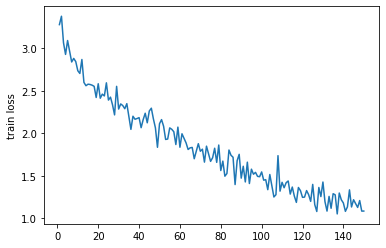

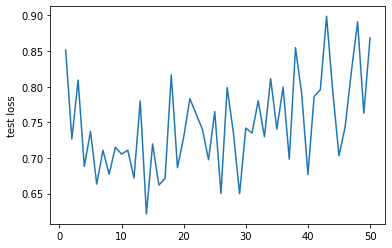

Finished Training


In [ ]:
import os
from torch import nn
os.environ['CUDA_LAUNCH_BLOCKING'] = '1'
device = torch.device( 'cuda' if torch.cuda.is_available() else 'cpu')
train_test(vgg19.to(device),50,100)

[1,  100] loss:1.112
[1,  200] loss:0.923
[1,  300] loss:1.107
Test set: Average loss: 0.7797
[2,  100] loss:1.030
[2,  200] loss:0.996
[2,  300] loss:1.123
Test set: Average loss: 0.8729
[3,  100] loss:1.104
[3,  200] loss:0.900
[3,  300] loss:1.006
Test set: Average loss: 0.8376
[4,  100] loss:1.042
[4,  200] loss:1.088
[4,  300] loss:0.989
Test set: Average loss: 1.0052
[5,  100] loss:0.964
[5,  200] loss:1.099
[5,  300] loss:1.092
Test set: Average loss: 0.8960
[6,  100] loss:1.076
[6,  200] loss:0.859
[6,  300] loss:0.897
Test set: Average loss: 0.8945
[7,  100] loss:0.856
[7,  200] loss:1.203
[7,  300] loss:0.973
Test set: Average loss: 0.8145
[8,  100] loss:1.056
[8,  200] loss:0.939
[8,  300] loss:0.964
Test set: Average loss: 0.8632
[9,  100] loss:0.824
[9,  200] loss:1.010
[9,  300] loss:0.974
Test set: Average loss: 0.8613
[10,  100] loss:0.993
[10,  200] loss:0.887
[10,  300] loss:1.012
Test set: Average loss: 0.8244
[11,  100] loss:1.040
[11,  200] loss:0.901
[11,  300] lo

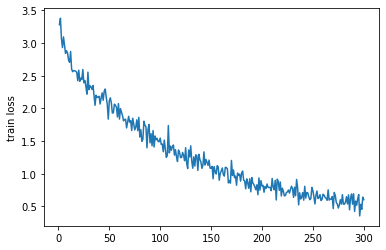

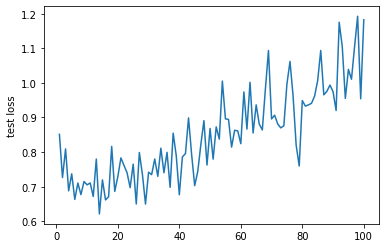

Finished Training


In [ ]:
import os
from torch import nn
os.environ['CUDA_LAUNCH_BLOCKING'] = '1'
device = torch.device( 'cuda' if torch.cuda.is_available() else 'cpu')
model = torch.load('/content/drive/MyDrive/yoga/models/downdog/YogaEvaNet_downdog_contrast1.pkl')
train_test2(model.to(device),50,100)

[1,  100] loss:0.496
[1,  200] loss:0.656
[1,  300] loss:0.515
Test set: Average loss: 1.2822
[2,  100] loss:0.429
[2,  200] loss:0.577
[2,  300] loss:0.635
Test set: Average loss: 1.1719
[3,  100] loss:0.675
[3,  200] loss:0.620
[3,  300] loss:0.474
Test set: Average loss: 1.0941
[4,  100] loss:0.464
[4,  200] loss:0.575
[4,  300] loss:0.448
Test set: Average loss: 1.0489
[5,  100] loss:0.396
[5,  200] loss:0.717
[5,  300] loss:0.379
Test set: Average loss: 1.1505
[6,  100] loss:0.534
[6,  200] loss:0.425
[6,  300] loss:0.504
Test set: Average loss: 0.9589
[7,  100] loss:0.546
[7,  200] loss:0.523
[7,  300] loss:0.564
Test set: Average loss: 1.2303
[8,  100] loss:0.589
[8,  200] loss:0.464
[8,  300] loss:0.536
Test set: Average loss: 1.2017
[9,  100] loss:0.635
[9,  200] loss:0.501
[9,  300] loss:0.452
Test set: Average loss: 1.0000
[10,  100] loss:0.458
[10,  200] loss:0.457
[10,  300] loss:0.474
Test set: Average loss: 1.1549
[11,  100] loss:0.559
[11,  200] loss:0.433
[11,  300] lo

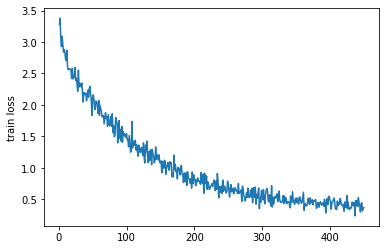

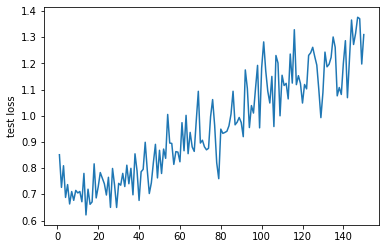

Finished Training


In [ ]:
import os
from torch import nn
os.environ['CUDA_LAUNCH_BLOCKING'] = '1'
device = torch.device( 'cuda' if torch.cuda.is_available() else 'cpu')
model = torch.load('/content/drive/MyDrive/yoga/models/downdog/YogaEvaNet_downdog_contrast1.pkl')
train_test2(model.to(device),50,100)

In [ ]:
#训练100个epoch的测试精度
device = torch.device( 'cuda' if torch.cuda.is_available() else 'cpu')
model = torch.load('/content/drive/MyDrive/yoga/models/downdog/YogaEvaNet_downdog_contrast1.pkl')
model.to(device)
print("测试精度如下：")
test(model)

测试精度如下：
测试集精度为：75%
测试集中不标准动作图片的预测精度为：59%
测试集中标准动作图片的预测精度为：87%
混淆矩阵为：
col_0  0.0  1.0
row_0          
0.0     19   13
1.0      5   35


In [ ]:
#训练150个epoch的测试精度
device = torch.device( 'cuda' if torch.cuda.is_available() else 'cpu')
model = torch.load('/content/drive/MyDrive/yoga/models/downdog/YogaEvaNet_downdog_contrast1.pkl')
model.to(device)
print("测试精度如下：")
test(model)

测试精度如下：
测试集精度为：70%
测试集中不标准动作图片的预测精度为：56%
测试集中标准动作图片的预测精度为：82%
混淆矩阵为：
col_0  0.0  1.0
row_0          
0.0     18   14
1.0      7   33
